<a href="https://colab.research.google.com/github/Fauzi455/PCVK26_12_M-Fauzi-R/blob/main/Week5_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Mohamat Fauzi Rohman'
NIM = '244107020067' # ganti dengan NIM Anda
N = int(NIM[-3:])
PARAM = {
'bins' : 2 ** ((N % 4) + 3),
'clip' : round(1.0 + (N % 5) * 0.5, 1),
'tile' : (N % 4) + 2,
'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
  print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Mohamat Fauzi Rohman
NIM : 244107020067 | N = 67
bins   : 64
clip   : 2.0
tile   : 5
L      : 4
WAKTU : 2026-09-21 13:56:28 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 17f2924a0a7970dc


#E. PERCOBAAN PRAKTIKUM


**E-1 PERCOBAAN HISTOGRAM**

1. Buka https://colab.research.google.com/. Setelah dipastikan bahwa Google Colab
terhubung dengan GitHub Anda, lanjutkan dengan memilih repository yang telah
digunakan pada praktikum minggu lalu, lalu ubah nama berkas menjadi
"Week5_No Absen.ipynb".
Kemudian import folder yang ada di Drive Anda dengan cara sebagai berikut.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Import beberapa library berikut yang akan digunakan selama uji coba praktikum
minggu ke-5 berikut.

In [7]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob


Membuat histogram citra berdasarkan flowchart di bawah ini. Tahap 1 gunakan citra
contoh lena.jpg dan cocokkan keluarannya dengan gambar contoh pada modul;
setelah cocok, tahap 2 ulangi dengan citra KTM1b.jpg milik Anda sendiri.

<BarContainer object of 256 artists>

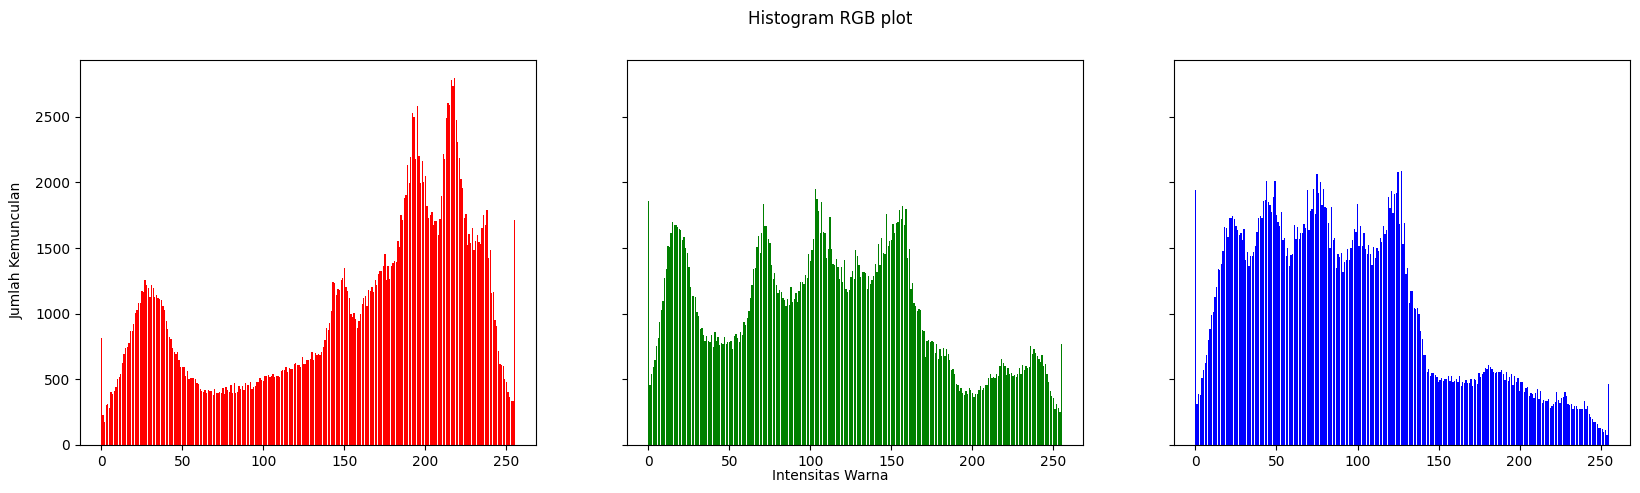

In [9]:
#membuat histogram image (manual) lena.jpg
img = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020067/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

<BarContainer object of 256 artists>

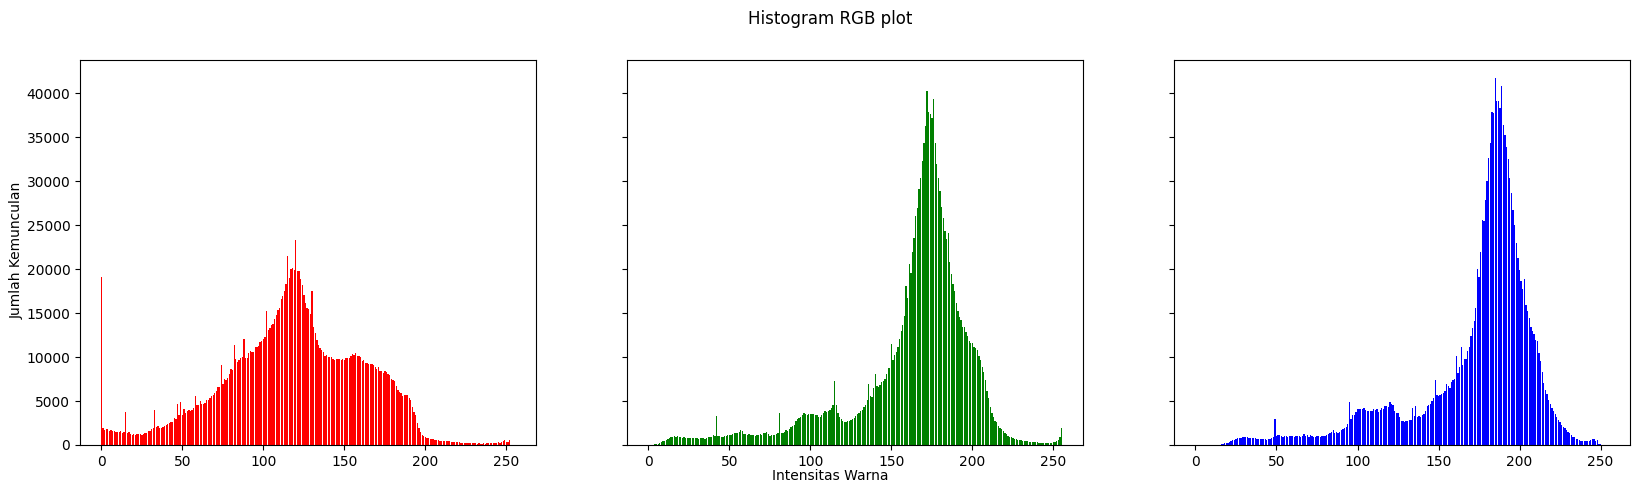

In [10]:
#membuat histogram image (manual) KTP1b.jpeg
img = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020067/KTP1b.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

**PERTANYAAN PRAKTIKUM E1**
1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.


2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.

3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.